In [1]:
# --- LIBRARIES ---
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
from PIL import Image

# Your local framework imports
from framework import generate_group_folds, run_fold_with_trainer
# import framework
# importlib.reload(framework)
from framework import WheatFramework, generate_group_folds,save_model, save_results, run_fold_with_trainer


CHANGE ACCORDING TO YOUR PATHS !!

In [2]:

# Update paths if different on your machine
excel_path = r".\labeling.xlsx"
data_path = r".\data"


Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\10X\02_02-2014_01_01-10_09-K1-10X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\10X\02_02-2014_01_02-10_09-K1-10X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\10X\02_02-2014_01_03-10_10-K1-10X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\10X\02_02-2014_01_05-10_10-K1-10X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\10X\02_02-2014_01_06-10_10-K1-10X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\10X\02_02-2014_01_07-09_51-K1-10X.jpeg (matched date 

,path,label
0,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
1,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
2,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
3,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
4,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
5,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
6,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
7,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0


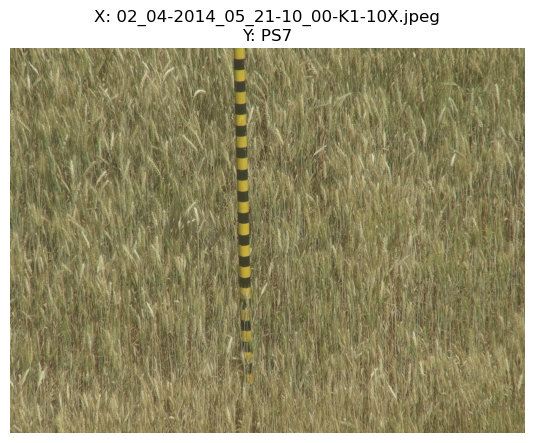

In [3]:

wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.get_dataframe()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    # Print label mapping (encoded -> string label)
    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[['path', 'label']].head(8))

    # Visual verification: display one random sample image and its label
    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [4]:
# Count images by group and stage
import pandas as pd

if 'meta_df' not in globals() or meta_df.empty:
    print("No `meta_df` available. Run the loader cell first (the one that creates `meta_df`).")
else:
    ct = pd.crosstab(meta_df['group_id'], meta_df['label'])
    ct['total'] = ct.sum(axis=1)
    ct = ct.sort_values('total', ascending=False)

    print('\nImages per group × stage (top 20 groups):')
    display(ct.head(20))

    print('\nStage totals:')
    stage_totals = ct.drop(columns=['total']).sum(axis=0).to_frame(name='count')
    display(stage_totals)



Images per group × stage (top 20 groups):


label,PS0,PS1,PS2,PS3,PS4,PS5,PS6,PS7,total
group_id,,,,,,,,,
7,90,12,15,6,14,21,12,28,198
6,22,20,34,28,47,4,18,16,189
10,31,24,18,28,35,13,25,14,188
1,20,19,37,15,47,12,8,23,181
9,101,17,15,5,15,8,20,0,181
2,11,37,21,24,22,9,19,30,173
3,19,22,26,40,26,14,10,16,173
4,7,36,5,18,36,15,13,31,161
8,44,14,17,4,39,21,3,17,159



Stage totals:


,count
label,
PS0,356
PS1,219
PS2,208
PS3,190
PS4,306
PS5,123
PS6,142
PS7,193


In [5]:
missing_data_per_station, missing_dates_for_stations = wf.get_stagewise_missing_data()



Stage: PS0

Stage: PS1

Stage: PS2

Stage: PS3


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in


Stage: PS4

Stage: PS5

Stage: PS6

Stage: PS7


c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  count = df_data[df_data['station_year'] == station][df_data['label'] == stage].shape[0]
c:\Users\PC\Desktop\AI_TARBIL\code\framework.py:144: UserWarning: Boolean Series key will be reindexed to match DataFrame in

In [6]:

print("\nMissing data per station:")
##make a table with station, stage, and only missing count
print("Station\t", end="")
for i in range(1,9):
    print(f"\tPS{i}", end="")
print()
for station, stages in missing_data_per_station.items():
    print(f"{station}", end="")
    for stage, info in stages.items():
        print(f"\t{info['missing_count']}", end="")
    print()


Missing data per station:
Station		PS1	PS2	PS3	PS4	PS5	PS6	PS7	PS8
02.02_2014	2	1	0	0	9	4	3	12
02.03_2013	3	14	3	11	14	0	2	1
02.03_2014	1	0	3	14	4	6	3	6
02.04_2013	14	8	13	1	9	0	0	-1
02.05_2013	29	0	7	4	20	2	8	17
02.06_2016	3	14	2	1	0	10	2	-1
06.01_2013	23	13	0	0	15	2	0	-1
06.02_2013	11	2	8	14	5	0	15	3
06.02_2016	62	4	6	4	17	2	13	15
11.03_2016	18	4	2	0	4	8	0	1


In [7]:
missing_data_per_station["02.06_2016"]

{'PS0': {'missing_count': 3,
  'total_days': 25,
  'data_count': 22,
  'days': {'start': Timestamp('2016-11-12 00:00:00'),
   'end': Timestamp('2016-12-07 00:00:00'),
   'days': 25}},
 'PS1': {'missing_count': 14,
  'total_days': 34,
  'data_count': 20,
  'days': {'start': Timestamp('2016-12-07 00:00:00'),
   'end': Timestamp('2017-01-10 00:00:00'),
   'days': 34}},
 'PS2': {'missing_count': 2,
  'total_days': 36,
  'data_count': 34,
  'days': {'start': Timestamp('2017-01-10 00:00:00'),
   'end': Timestamp('2017-02-15 00:00:00'),
   'days': 36}},
 'PS3': {'missing_count': 1,
  'total_days': 29,
  'data_count': 28,
  'days': {'start': Timestamp('2017-02-15 00:00:00'),
   'end': Timestamp('2017-03-16 00:00:00'),
   'days': 29}},
 'PS4': {'missing_count': 0,
  'total_days': 47,
  'data_count': 47,
  'days': {'start': Timestamp('2017-03-16 00:00:00'),
   'end': Timestamp('2017-05-02 00:00:00'),
   'days': 47}},
 'PS5': {'missing_count': 10,
  'total_days': 14,
  'data_count': 4,
  'days': 

In [8]:
missing_dates_for_stations

{'02.02_2014': {Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00'),
  Timestamp('2015-06-14 00:00:00'),
  Timestamp('2015-06-15 00:00:00'),
  Timestamp('2015-06-16 00:00:00'),
  Timestamp('2015-06-17 00:00:00'),
  Timestamp('2015-06-18 00:00:00'),
  Timestamp('2015-06-19 00:00:00'),
  Timestamp('2015-06-30 00:00:00'),
  Timestamp('2015-07-01 00:00:00')},
 '02.03_2013': {Timestamp('2014-05-30 00:00:00'),
  Timestamp('2014-06-12 00:00:00')},
 '02.03_2014': {Timestamp('2015-05-24 00:00:00'),
  Timestamp('2015-05-25 00:00:00'),
  Timestamp('2015-05-30 00:00:00'),
  Timestamp('2015-06-07 00:00:00'),
  Timestamp('2015-06-11 00:00:00'),
  Timestamp('2015-06-12 00:00:00'),
  Timestamp('2015-06-13 00:00:00')},
 '02.04_2013': {Timestamp('2014-03-17 00:00:00'),
  Timestamp('2014-03-18 00:00:00'),
  Timestamp('2014-03-19 00:00:00'),
  Timestamp('2014-03-20 00:00:00'),
  Tim

In [9]:
if 'meta_df' in globals() and not meta_df.empty:
    example_folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
    print('\nGenerated', len(example_folds), 'folds. Sample sizes:')
    for i, (tr, te) in enumerate(example_folds, 1):
        print(f' Fold {i}: train_samples={len(tr)}, test_samples={len(te)}')
else:
    print('meta_df not found — run loader cell first to generate folds.')



Generated 5 folds. Sample sizes:
 Fold 1: train_samples=1358, test_samples=379
 Fold 2: train_samples=1375, test_samples=362
 Fold 3: train_samples=1383, test_samples=354
 Fold 4: train_samples=1403, test_samples=334
 Fold 5: train_samples=1383, test_samples=354


YOUR CODE HERE

In [10]:

# ---------------------
# EXAMPLES / TEMPLATES
# ---------------------

# Example: simple sklearn-like trainer function (for models with fit/predict APIs)
# def sklearn_trainer(train_df, test_df, fold_id):
#     # transform paths -> features as needed (e.g., load images and compute embeddings)
#     X_train, y_train = preprocess_paths_to_array(train_df['path'], train_df['label'])
#     X_test, y_test = preprocess_paths_to_array(test_df['path'], test_df['label'])
#     from sklearn.ensemble import RandomForestClassifier
#     model = RandomForestClassifier(n_estimators=100)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)
#     # build predictions DataFrame
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': y_test, 'pred': preds})
#     metrics = {'accuracy': (pred_df['true'] == pred_df['pred']).mean()}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: PyTorch training skeleton (user must implement dataset, dataloader, model, optimizer)
# def pytorch_trainer(train_df, test_df, fold_id):
#     import torch
#     # implement Dataset that loads images from `path` and returns tensors + labels
#     train_dataset = MyImageDataset(train_df)
#     test_dataset = MyImageDataset(test_df)
#     train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
#     test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)
#     model = MyNet()
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     loss_fn = torch.nn.CrossEntropyLoss()
#     # training loop ...
#     # after training produce preds and metrics
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': true_labels, 'pred': pred_labels})
#     metrics = {'accuracy': accuracy}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: YOLO/Ultralytics style (pseudo)
# def yolov5_trainer(train_df, test_df, fold_id):
#     # prepare yaml/train.txt and yaml/val.txt listing image paths
#     # call ultralytics/train.py with appropriate args
#     # after training, load results and return predictions+metrics
#     pass

# ---------------------
# Quick sanity check: create a small set of folds and print counts


In [ ]:
# --- 1. Constants & Feature Extraction (From your working Date code) ---
TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85)

def prepare_advanced_features(df):
    df = df.copy()
    
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        if not match:
            return pd.NaT
        return pd.to_datetime(match.group(1).replace('-', '_'), format='%Y_%m_%d', errors='coerce')

    df['dt'] = df['path'].apply(extract_date)
    
    def get_agricultural_doy(date):
        if pd.isna(date):
            return np.nan
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    df['date_missing'] = df['dt'].isna().astype(np.float32)
    
    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)
    
    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]
    
    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]
    
    return df


# --- 2. Multimodal Tiled Dataset ---
class MultimodalTiledDataset(Dataset):
    def __init__(self, df, label_map, transform=None, is_training=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_training = is_training
        self.label_map = label_map

    def __len__(self):
        return len(self.df) * 4 if self.is_training else len(self.df)

    def __getitem__(self, idx):
        original_idx = idx // 4 if self.is_training else idx
        row = self.df.iloc[original_idx]
        
        img = Image.open(row['path']).convert('RGB')
        w, h = img.size
        coords = [(0, 0, w//2, h//2), (w//2, 0, w, h//2), (0, h//2, w//2, h), (w//2, h//2, w, h)]
        
        if self.is_training:
            tile_pos = idx % 4
            img_data = img.crop(coords[tile_pos])
            if self.transform:
                img_data = self.transform(img_data)
        else:
            tiles = [img.crop(c) for c in coords]
            if self.transform:
                tiles = [self.transform(t) for t in tiles]
            img_data = torch.stack(tiles)

        agri_day = row['agri_day_of_year']
  
        lat_norm = row['latitude']
        lon_norm = row['longitude']

        meta_tensor = torch.tensor([agri_day, lat_norm, lon_norm], dtype=torch.float32)
        label_tensor = torch.tensor(self.label_map[row['label']], dtype=torch.long)

        return img_data, meta_tensor, label_tensor


# --- 3. Multimodal Architecture ---
class MultimodalViT(nn.Module):
    def __init__(self, num_classes):
        super(MultimodalViT, self).__init__()
        
        from torchvision.models.vision_transformer import interpolate_embeddings

        weights = models.ViT_B_16_Weights.DEFAULT
        vit_num = 2

        self.vit_arr = nn.ModuleList([
            models.vit_b_16(weights=None, image_size=448)
            for _ in range(vit_num)
        ])

        state_dict = weights.get_state_dict(progress=True)

        state_dict = interpolate_embeddings(
            image_size=448,
            patch_size=16,
            model_state=state_dict,
            reset_heads=True
        )

        # get feature dimension BEFORE replacing heads
        vit_dim = self.vit_arr[0].heads.head.in_features

        for vit in self.vit_arr:
            vit.load_state_dict(state_dict, strict=False)
            vit.heads = nn.Identity()

        self.meta_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 128),
            nn.GELU()
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(vit_num* vit_dim + 128, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, meta):
        # print("Input image shape:", img.shape)  # Debug print
        v_features = torch.cat([vit(img) for vit in self.vit_arr], dim=1)
        m_features = self.meta_net(meta)
        combined = torch.cat((v_features, m_features), dim=1)
        return self.classifier(combined)


# --- 4. Trainer ---
def multimodal_tiled_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_size = config.get('img_size', 224)

    all_labels = sorted(train_df['label'].unique())
    label_map = {label: i for i, label in enumerate(all_labels)} 
    inv_map = {v: k for k, v in label_map.items()}
    num_classes = len(all_labels)

    for df_ in [train_df, test_df]:
        df_["latitude"] = df_["latitude"].fillna(39.93)
        df_["longitude"] = df_["longitude"].fillna(32.85)

        df_["latitude"] = (df_["latitude"] - 36.20) / (41.73 - 36.20)
        df_["longitude"] = (df_["longitude"] - 26.39) / (43.73 - 26.39)
        
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ])

    test_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ])

    train_loader = DataLoader(
        MultimodalTiledDataset(train_df, label_map, train_transform, is_training=True), 
        batch_size=config['batch_size'],
        shuffle=True
    )

    test_loader = DataLoader(
        MultimodalTiledDataset(test_df, label_map, test_transform, is_training=False), 
        batch_size=1,
        shuffle=False
    )

    model = MultimodalViT(num_classes).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_pred_df = None
    best_model_state = None

    print(f"\n{'='*40}")
    print(f"🚀 STARTING MULTIMODAL FOLD: {fold_id}")
    print(f"{'='*40}")
    acc_not_increased_epoch_num = 0
    for epoch in range(config['epochs']):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
    
        
        for i, (imgs, metas, lbls) in enumerate(train_loader):
            imgs, metas, lbls = imgs.to(device), metas.to(device), lbls.to(device)
            optimizer.zero_grad()
            
            outputs = model(imgs, metas)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

            if (i + 1) % 10 == 0:
                print(f"  Epoch [{epoch+1}/{config['epochs']}] | Batch [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end='\r')


        model.eval()
        all_preds, all_trues = [], []

        with torch.no_grad():
            for tiled_img, meta, lbl in test_loader:
                tiled_img = tiled_img.squeeze(0).to(device)   # (4, C, H, W)
                meta = meta.to(device)                        # (1, 5)
                meta_repeated = meta.repeat(4, 1)            # (4, 5)

                outputs = model(tiled_img, meta_repeated)    # (4, num_classes)
                avg_output = torch.mean(outputs, dim=0)      # (num_classes,)

                pred = torch.argmax(avg_output).cpu().item()
                all_preds.append(pred)
                all_trues.append(lbl.item())

        fold_acc = np.mean(np.array(all_preds) == np.array(all_trues))

        print(f"▶️ Epoch {epoch+1} Complete: train Loss: {running_loss/len(train_loader):.4f} |train Acc: {100.*correct/total:.2f}% | test Acc: {fold_acc:.4f}")
        
        if fold_acc <= best_acc:
            acc_not_increased_epoch_num = (acc_not_increased_epoch_num + 1)
        else:
            acc_not_increased_epoch_num = 0
            print(f"  🎉 New best accuracy: {fold_acc:.4f} (previous: {best_acc:.4f}). Saving model state.")
            best_acc = fold_acc
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            #if model accuracy over 80% save the model to disk immediately with a special name
            if best_acc >= 0.80:
                save_model(model, f'vtmm/fold_{fold_id}_acc{best_acc:.4f}.pth')
                print(f"  🎉 Accuracy over 80%! Model saved as 'fold_{fold_id}_acc{best_acc:.4f}.pth'.")
            best_pred_df = pd.DataFrame({
                'path': test_df['path'].values,
                'true': [inv_map[t] for t in all_trues],
                'pred': [inv_map[p] for p in all_preds]
            })
            # create a graph to show which classes are being mixed up the most (confusion matrix or similar) and save it to disk for later
            import matplotlib.pyplot as plt
            import seaborn as sns
            plt.figure(figsize=(6,5))
            sns.heatmap(pd.crosstab(pd.Series(all_trues, name='True'), pd.Series(all_preds, name='Pred')), annot=True, fmt='d', cmap='Blues')
            plt.title(f'Fold {fold_id} - Epoch {epoch+1} Confusion Matrix')
            plt.savefig(f'vtmm/fold_{fold_id}_confusion_matrix.png')
            plt.close() 
        print(f"  Accuracy not improved for {acc_not_increased_epoch_num} epochs.") if acc_not_increased_epoch_num > 0 else print("  Accuracy improved! Resetting counter.")
        if acc_not_increased_epoch_num >= 3:
            print(f"⚠️  Accuracy has not improved for {acc_not_increased_epoch_num} epochs. Early stopping at epoch {epoch+1}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"✅ FOLD {fold_id} ACCURACY: {best_acc:.4f}\n")
    return {'model': model, 'predictions': best_pred_df, 'metrics': {'accuracy': best_acc}}


# --- 5. Execution ---
multi_config = {
    'img_size': 448,
    'batch_size': 8, 
    'lr': 3e-5,      
    'epochs': 10
}

meta_df_advanced = prepare_advanced_features(meta_df)

folds = generate_group_folds(meta_df_advanced, n_train=8, n_test=2, num_folds=5, group_col='group_id', random_state=42)
multi_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df_advanced,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: multimodal_tiled_trainer(tr, te, fid, multi_config),
        fold_id=f_idx + 1
    )
    multi_metrics.append(result['metrics']['accuracy'])

print(f"\n{'-'*50}")
print(f"FINAL MULTIMODAL MEAN ACCURACY: {np.mean(multi_metrics):.4f}")
print(f"{'-'*50}")

c:\Users\PC\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1355: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  return t.to(



🚀 STARTING MULTIMODAL FOLD: 1
▶️ Epoch 1 Complete: train Loss: 0.8431 |train Acc: 70.99% | test Acc: 0.5224
  🎉 New best accuracy: 0.5224 (previous: 0.0000). Saving model state.
  Accuracy improved! Resetting counter.
▶️ Epoch 2 Complete: train Loss: 0.3553 |train Acc: 87.04% | test Acc: 0.5963
  🎉 New best accuracy: 0.5963 (previous: 0.5224). Saving model state.
  Accuracy improved! Resetting counter.
▶️ Epoch 3 Complete: train Loss: 0.2608 |train Acc: 90.39% | test Acc: 0.5092
  Accuracy not improved for 1 epochs.
▶️ Epoch 4 Complete: train Loss: 0.2176 |train Acc: 91.97% | test Acc: 0.4380
  Accuracy not improved for 2 epochs.
▶️ Epoch 5 Complete: train Loss: 0.1752 |train Acc: 93.58% | test Acc: 0.5172
  Accuracy not improved for 3 epochs.
⚠️  Accuracy has not improved for 3 epochs. Early stopping at epoch 5.
✅ FOLD 1 ACCURACY: 0.5963


🚀 STARTING MULTIMODAL FOLD: 2
▶️ Epoch 1 Complete: train Loss: 0.8233 |train Acc: 71.98% | test Acc: 0.4503
  🎉 New best accuracy: 0.4503 (previou

both 1x and 10X image 2 vit: 61%
5 vit: only one fold: 63%
2 vit: 67%

In [12]:
# --- 1. Constants & Feature Extraction (From your working Date code) ---
TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15)
}
DEFAULT_COORD = (39.93, 32.85)

def prepare_advanced_features(df):
    df = df.copy()
    
    def extract_date(path):
        match = re.search(r'(\d{4}[_-]\d{2}[_-]\d{2})', str(path))
        if not match:
            return pd.NaT
        return pd.to_datetime(match.group(1).replace('-', '_'), format='%Y_%m_%d', errors='coerce')

    df['dt'] = df['path'].apply(extract_date)
    
    def get_agricultural_doy(date):
        if pd.isna(date):
            return np.nan
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df['agri_day_of_year'] = df['dt'].apply(get_agricultural_doy)
    df['date_missing'] = df['dt'].isna().astype(np.float32)
    
    df['plate_code'] = df['station_year'].astype(str).str.extract(r'^(\d{2})')[0].astype(float)
    
    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]
    
    coords = df['plate_code'].apply(get_lat_lon)
    df['latitude'] = [c[0] for c in coords]
    df['longitude'] = [c[1] for c in coords]
    
    return df


# --- 2. Multimodal Tiled Dataset ---
class MultimodalTiledDataset(Dataset):
    def __init__(self, df, label_map, transform=None, is_training=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_training = is_training
        self.label_map = label_map

    def __len__(self):
        return len(self.df) * 4 if self.is_training else len(self.df)

    def __getitem__(self, idx):
        original_idx = idx // 4 if self.is_training else idx
        row = self.df.iloc[original_idx]
        
        img = Image.open(row['path']).convert('RGB')
        w, h = img.size
        coords = [(0, 0, w//2, h//2), (w//2, 0, w, h//2), (0, h//2, w//2, h), (w//2, h//2, w, h)]
        
        if self.is_training:
            tile_pos = idx % 4
            img_data = img.crop(coords[tile_pos])
            if self.transform:
                img_data = self.transform(img_data)
        else:
            tiles = [img.crop(c) for c in coords]
            if self.transform:
                tiles = [self.transform(t) for t in tiles]
            img_data = torch.stack(tiles)

        agri_day = row['agri_day_of_year']
  
        lat_norm = row['latitude']
        lon_norm = row['longitude']

        meta_tensor = torch.tensor([agri_day, lat_norm, lon_norm], dtype=torch.float32)
        label_tensor = torch.tensor(self.label_map[row['label']], dtype=torch.long)

        return img_data, meta_tensor, label_tensor


# --- 3. Multimodal Architecture ---
class MultimodalViT(nn.Module):
    def __init__(self, num_classes):
        super(MultimodalViT, self).__init__()
        
        from torchvision.models.vision_transformer import interpolate_embeddings

        weights = models.ViT_B_16_Weights.DEFAULT

        self.vit = models.vit_b_16(weights=None, image_size=448)

        state_dict = weights.get_state_dict(progress=True)

        state_dict = interpolate_embeddings(
            image_size=448,
            patch_size=16,
            model_state=state_dict,
            reset_heads=True
)

        self.vit.load_state_dict(state_dict, strict=False)

        vit_dim = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()
                
        self.meta_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 128),
            nn.GELU()
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(vit_dim + 128, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, meta):
        # print("Input image shape:", img.shape)  # Debug print
        v_features = self.vit(img)
        m_features = self.meta_net(meta)
        combined = torch.cat((v_features, m_features), dim=1)
        return self.classifier(combined)


# --- 4. Trainer ---
def multimodal_tiled_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_size = config.get('img_size', 224)

    all_labels = sorted(train_df['label'].unique())
    label_map = {label: i for i, label in enumerate(all_labels)} 
    inv_map = {v: k for k, v in label_map.items()}
    num_classes = len(all_labels)

    for df_ in [train_df, test_df]:
        df_["latitude"] = df_["latitude"].fillna(39.93)
        df_["longitude"] = df_["longitude"].fillna(32.85)

        df_["latitude"] = (df_["latitude"] - 36.20) / (41.73 - 36.20)
        df_["longitude"] = (df_["longitude"] - 26.39) / (43.73 - 26.39)
        
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ])

    test_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ])

    train_loader = DataLoader(
        MultimodalTiledDataset(train_df, label_map, train_transform, is_training=True), 
        batch_size=config['batch_size'],
        shuffle=True
    )

    test_loader = DataLoader(
        MultimodalTiledDataset(test_df, label_map, test_transform, is_training=False), 
        batch_size=1,
        shuffle=False
    )

    model = MultimodalViT(num_classes).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_pred_df = None
    best_model_state = None

    print(f"\n{'='*40}")
    print(f"🚀 STARTING MULTIMODAL FOLD: {fold_id}")
    print(f"{'='*40}")
    acc_not_increased_epoch_num = 0
    for epoch in range(config['epochs']):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
    
        
        for i, (imgs, metas, lbls) in enumerate(train_loader):
            imgs, metas, lbls = imgs.to(device), metas.to(device), lbls.to(device)
            optimizer.zero_grad()
            
            outputs = model(imgs, metas)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

            if (i + 1) % 10 == 0:
                print(f"  Epoch [{epoch+1}/{config['epochs']}] | Batch [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f}", end='\r')


        model.eval()
        all_preds, all_trues = [], []

        with torch.no_grad():
            for tiled_img, meta, lbl in test_loader:
                tiled_img = tiled_img.squeeze(0).to(device)   # (4, C, H, W)
                meta = meta.to(device)                        # (1, 5)
                meta_repeated = meta.repeat(4, 1)            # (4, 5)

                outputs = model(tiled_img, meta_repeated)    # (4, num_classes)
                avg_output = torch.mean(outputs, dim=0)      # (num_classes,)

                pred = torch.argmax(avg_output).cpu().item()
                all_preds.append(pred)
                all_trues.append(lbl.item())

        fold_acc = np.mean(np.array(all_preds) == np.array(all_trues))

        print(f"▶️ Epoch {epoch+1} Complete: train Loss: {running_loss/len(train_loader):.4f} |train Acc: {100.*correct/total:.2f}% | test Acc: {fold_acc:.4f}")
        
        # create a graph to show which classes are being mixed up the most (confusion matrix or similar) and save it to disk for later
        import matplotlib.pyplot as plt
        import seaborn as sns
        plt.figure(figsize=(6,5))
        sns.heatmap(pd.crosstab(pd.Series(all_trues, name='True'), pd.Series(all_preds, name='Pred')), annot=True, fmt='d', cmap='Blues')
        plt.title(f'Fold {fold_id} - Epoch {epoch+1} Confusion Matrix')
        plt.savefig(f'vtmm/fold_{fold_id}_epoch_{epoch+1}_confusion_matrix.png')
        plt.close() 
        if fold_acc <= best_acc:
            acc_not_increased_epoch_num = (acc_not_increased_epoch_num + 1)
        else:
            acc_not_increased_epoch_num = 0
            print(f"  🎉 New best accuracy: {fold_acc:.4f} (previous: {best_acc:.4f}). Saving model state.")
            best_acc = fold_acc
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_pred_df = pd.DataFrame({
                'path': test_df['path'].values,
                'true': [inv_map[t] for t in all_trues],
                'pred': [inv_map[p] for p in all_preds]
            })
        print(f"  Accuracy not improved for {acc_not_increased_epoch_num} epochs.") if acc_not_increased_epoch_num > 0 else print("  Accuracy improved! Resetting counter.")
        if acc_not_increased_epoch_num >= 3:
            print(f"⚠️  Accuracy has not improved for {acc_not_increased_epoch_num} epochs. Early stopping at epoch {epoch+1}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"✅ FOLD {fold_id} ACCURACY: {best_acc:.4f}\n")
    return {'model': model, 'predictions': best_pred_df, 'metrics': {'accuracy': best_acc}}


# --- 5. Execution ---
multi_config = {
    'img_size': 448, # we will tile 4 images of 448x448 to get an effective input size of 1792x1792, which is large but should be manageable with ViT and a strong GPU. Adjust if needed. 
    'batch_size': 8, 
    'lr': 3e-5,      
    'epochs': 10
}

meta_df_advanced = prepare_advanced_features(meta_df)

folds = generate_group_folds(meta_df_advanced, n_train=8, n_test=2, num_folds=5, group_col='group_id', random_state=42)
multi_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df_advanced,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: multimodal_tiled_trainer(tr, te, fid, multi_config),
        fold_id=f_idx + 1
    )
    multi_metrics.append(result['metrics']['accuracy'])

print(f"\n{'-'*50}")
print(f"FINAL MULTIMODAL MEAN ACCURACY: {np.mean(multi_metrics):.4f}")
print(f"{'-'*50}")


🚀 STARTING MULTIMODAL FOLD: 1
▶️ Epoch 1 Complete: train Loss: 0.9001 |train Acc: 67.23% | test Acc: 0.5289
  🎉 New best accuracy: 0.5289 (previous: 0.0000). Saving model state.
  Accuracy improved! Resetting counter.
▶️ Epoch 2 Complete: train Loss: 0.3958 |train Acc: 85.47% | test Acc: 0.5671
  🎉 New best accuracy: 0.5671 (previous: 0.5289). Saving model state.
  Accuracy improved! Resetting counter.
▶️ Epoch 3 Complete: train Loss: 0.2731 |train Acc: 90.15% | test Acc: 0.5092
  Accuracy not improved for 1 epochs.
▶️ Epoch 4 Complete: train Loss: 0.2170 |train Acc: 92.22% | test Acc: 0.5079
  Accuracy not improved for 2 epochs.
▶️ Epoch 5 Complete: train Loss: 0.1855 |train Acc: 93.54% | test Acc: 0.4605
  Accuracy not improved for 3 epochs.
⚠️  Accuracy has not improved for 3 epochs. Early stopping at epoch 5.
✅ FOLD 1 ACCURACY: 0.5671


🚀 STARTING MULTIMODAL FOLD: 2
▶️ Epoch 1 Complete: train Loss: 0.8062 |train Acc: 71.93% | test Acc: 0.4710
  🎉 New best accuracy: 0.4710 (previou